# Event Waveform Processing and Analysis

This notebook processes event waveforms from the Cascadia dataset:
1. Reads event and pick information from CSV files
2. Downloads waveforms from IRIS FDSN
3. Processes waveforms (resampling, filtering)
4. Calculates amplitudes for local magnitude estimation
5. Visualizes waveforms with picks

by Marine Denolle (mdenolle@uw.edu)

In [14]:
# Import required libraries
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import obspy
from obspy import UTCDateTime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.data_client import get_waveforms


In [15]:
# pnwstore is installed from source — run once if not already installed:
# git clone https://github.com/niyiyu/pnwstore.git && cd pnwstore && pip install .

In [28]:
# Set processing parameters
sample_rate = 100  # Hz
highpass_freq = 2  # Hz
window_after = 540  # seconds after origin time
window_before = 30  # seconds before origin time
P_before = 1 # second before the pick
P_after = 5 # seconds after the pick

# Data source: 'fdsn' (public EarthScope/IRIS) or 'pnwstore' (UW internal archive)
source = 'pnwstore'


In [29]:
# Read event and pick data
events_df = pd.read_csv('../data/Cascadia_relocated_catalog_ver_3.csv')
picks_df = pd.read_csv('../data/Cascadia_relocated_catalog_picks_ver_3.csv')

print("Event data summary:")
print(f"Number of events: {len(events_df)}")
print("\nFirst few events:")
print(events_df.head())

print("\nPick data summary:")
print(f"Number of picks: {len(picks_df)}")
print("\nFirst few picks:")
print(picks_df.head())

Event data summary:
Number of events: 63887

First few events:
   Latitude   Longitude   Depth (km)             Origin Time (UTC)  \
0  47.22533  -122.16895       56.111   2010-01-01T00:15:17.262282Z   
1  48.19518  -121.77276        3.820   2010-01-01T00:16:49.375360Z   
2  47.86208  -122.09903       17.799   2010-01-01T07:18:03.689209Z   
3  47.96435  -122.91906       21.286   2010-01-01T08:51:56.371091Z   
4  45.87262  -122.19180        9.822   2010-01-01T16:12:43.838660Z   

    Uncertainity (km)   Horizontal Uncertainity (km)   Geometric Std. (km)  \
0              10.223                         10.216                 0.790   
1               7.560                          3.786                 0.140   
2               5.118                          4.807                 0.195   
3               1.899                          1.884                 0.287   
4               2.842                          2.838                 0.229   

    Detection Value   Num. P   Num. S   RMS Res

In [35]:
def process_event(event_id, events_df, picks_df, source='fdsn'):
    """
    Process single event and return waveforms and metadata
    
    Parameters:
    -----------
    event_id : str
        Event identifier
    events_df : pandas.DataFrame
        DataFrame containing event information
    picks_df : pandas.DataFrame
        DataFrame containing pick information
    source : str
        Waveform backend: 'fdsn' (public EarthScope) or 'pnwstore' (UW internal archive)
    
    Returns:
    --------
    st : obspy.Stream
        Processed waveforms
    amplitudes : dict
        Peak amplitudes for each station (measured around each station's P pick)
    origin_time : UTCDateTime
        Event origin time
    """

    # window_before and window_after are defined globally
    global window_before, window_after, P_before, P_after
    # Get event information
    event_cols = [col for col in events_df.columns if 'event' in col.lower()][0]
    origin_cols = [col for col in events_df.columns if 'origin' in col.lower()][0]
    station_cols = [col for col in picks_df.columns if 'station' in col.lower()][0]
    # Column in picks_df that holds the pick time
    pick_time_col = [col for col in picks_df.columns if 'pick' in col.lower()][0]

    event = events_df[events_df[event_cols] == event_id].iloc[0]
    origin_time = UTCDateTime(event[origin_cols])
    
    # Get associated picks
    event_picks = picks_df[picks_df[event_cols] == event_id]
    # Storage for waveforms and amplitudes
    st = obspy.Stream()
    station_amplitudes = {}
    
    # Process each station's data
    for _, pick in event_picks.iterrows():
        try:
            # Get network and station codes (picks stored as "station.network")
            station, network = pick[station_cols].split('.')
            station = station.strip()
            network = network.strip()

            # Per-station P pick time — amplitude window is centred here, NOT on origin
            pick_time = UTCDateTime(pick[pick_time_col])

            # Download waveforms — routes to pnwstore (UW/internal) or FDSN (NC/BK/public)
            st_temp = get_waveforms(
                network=network,
                station=station,
                channel="*H*",
                starttime=origin_time - window_before,
                endtime=origin_time + window_after,
                source=source,
            )
            
            # Process each trace
            for tr in st_temp:
                tr.resample(sample_rate)
                tr.filter('highpass', freq=highpass_freq)
                st += tr
            
            st.plot()
                
            # Calculate amplitude around the P pick (P_before s before to P_after s after)
            station_amps = []
            for comp in ['Z', 'N', 'E']:
                comp_tr = st_temp.select(component=comp).copy()
                comp_tr.trim(starttime=pick_time - P_before, endtime=pick_time + P_after)
                if len(comp_tr) > 0:
                    station_amps.append(np.max(np.abs(comp_tr[0].data)))
                # plot the data for visual inspection
                comp_tr.plot()
            if station_amps:
                station_amplitudes[network + '.' + station] = np.mean(station_amps)
            
        except Exception as e:
            print(f"Error processing {network}.{station}: {e}")
            continue
    
    return st, station_amplitudes, origin_time


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


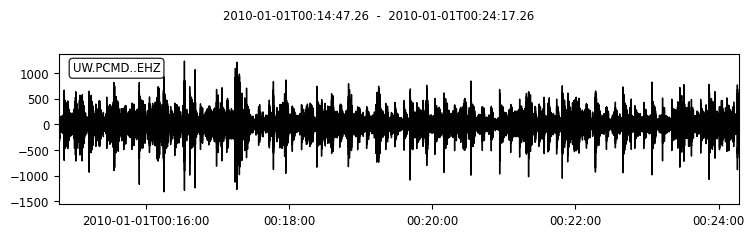

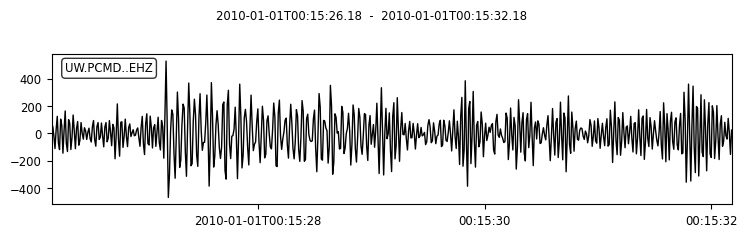

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Error processing UW.PCMD: Empty stream object


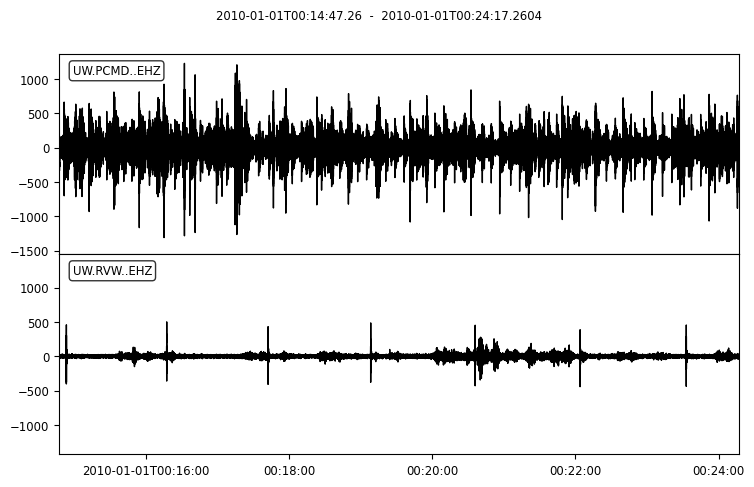

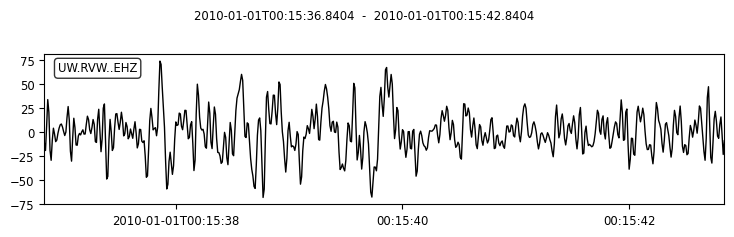

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Error processing UW.RVW: Empty stream object


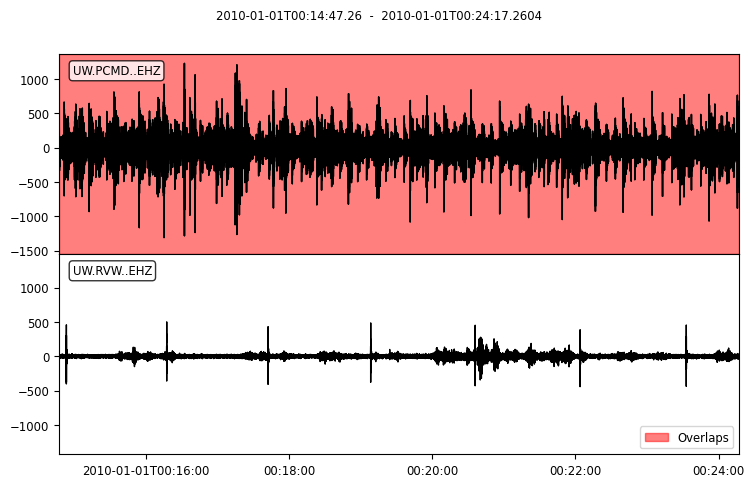

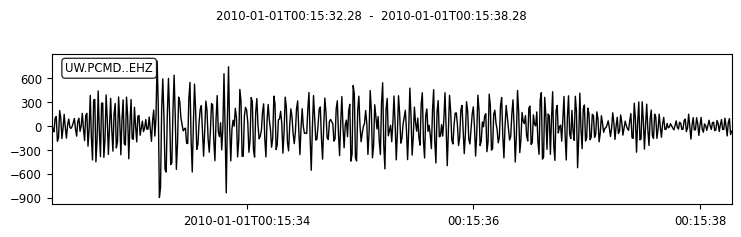

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Error processing UW.PCMD: Empty stream object


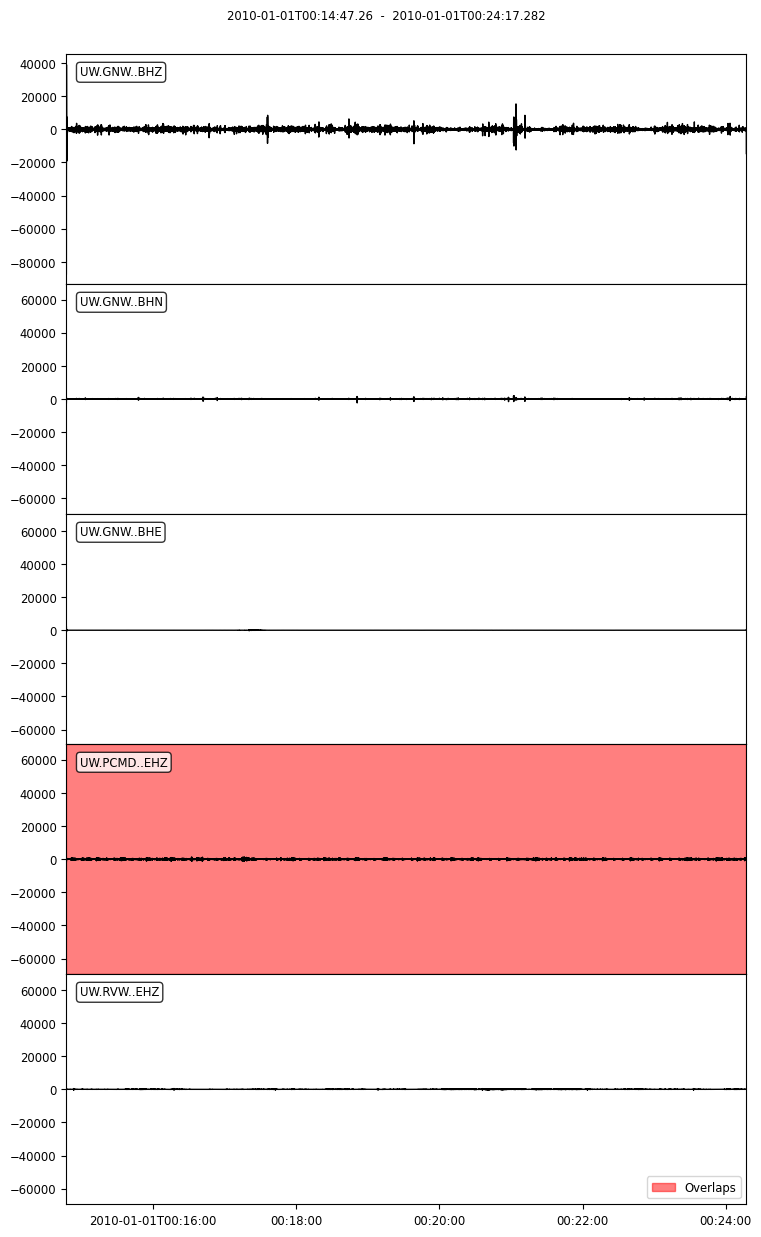

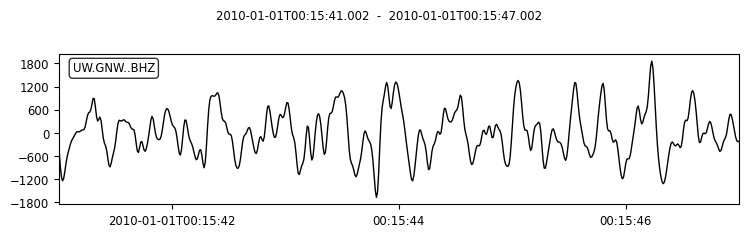

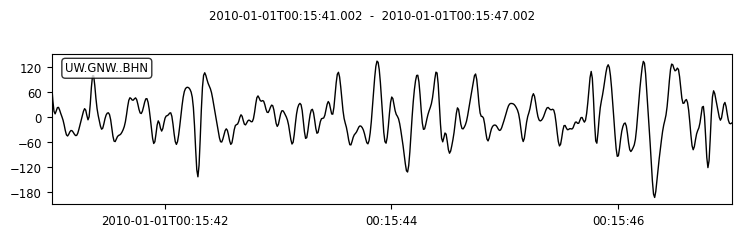

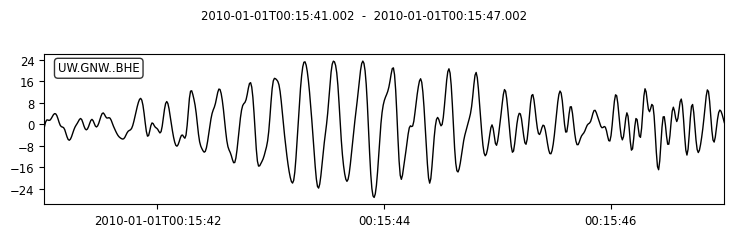

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


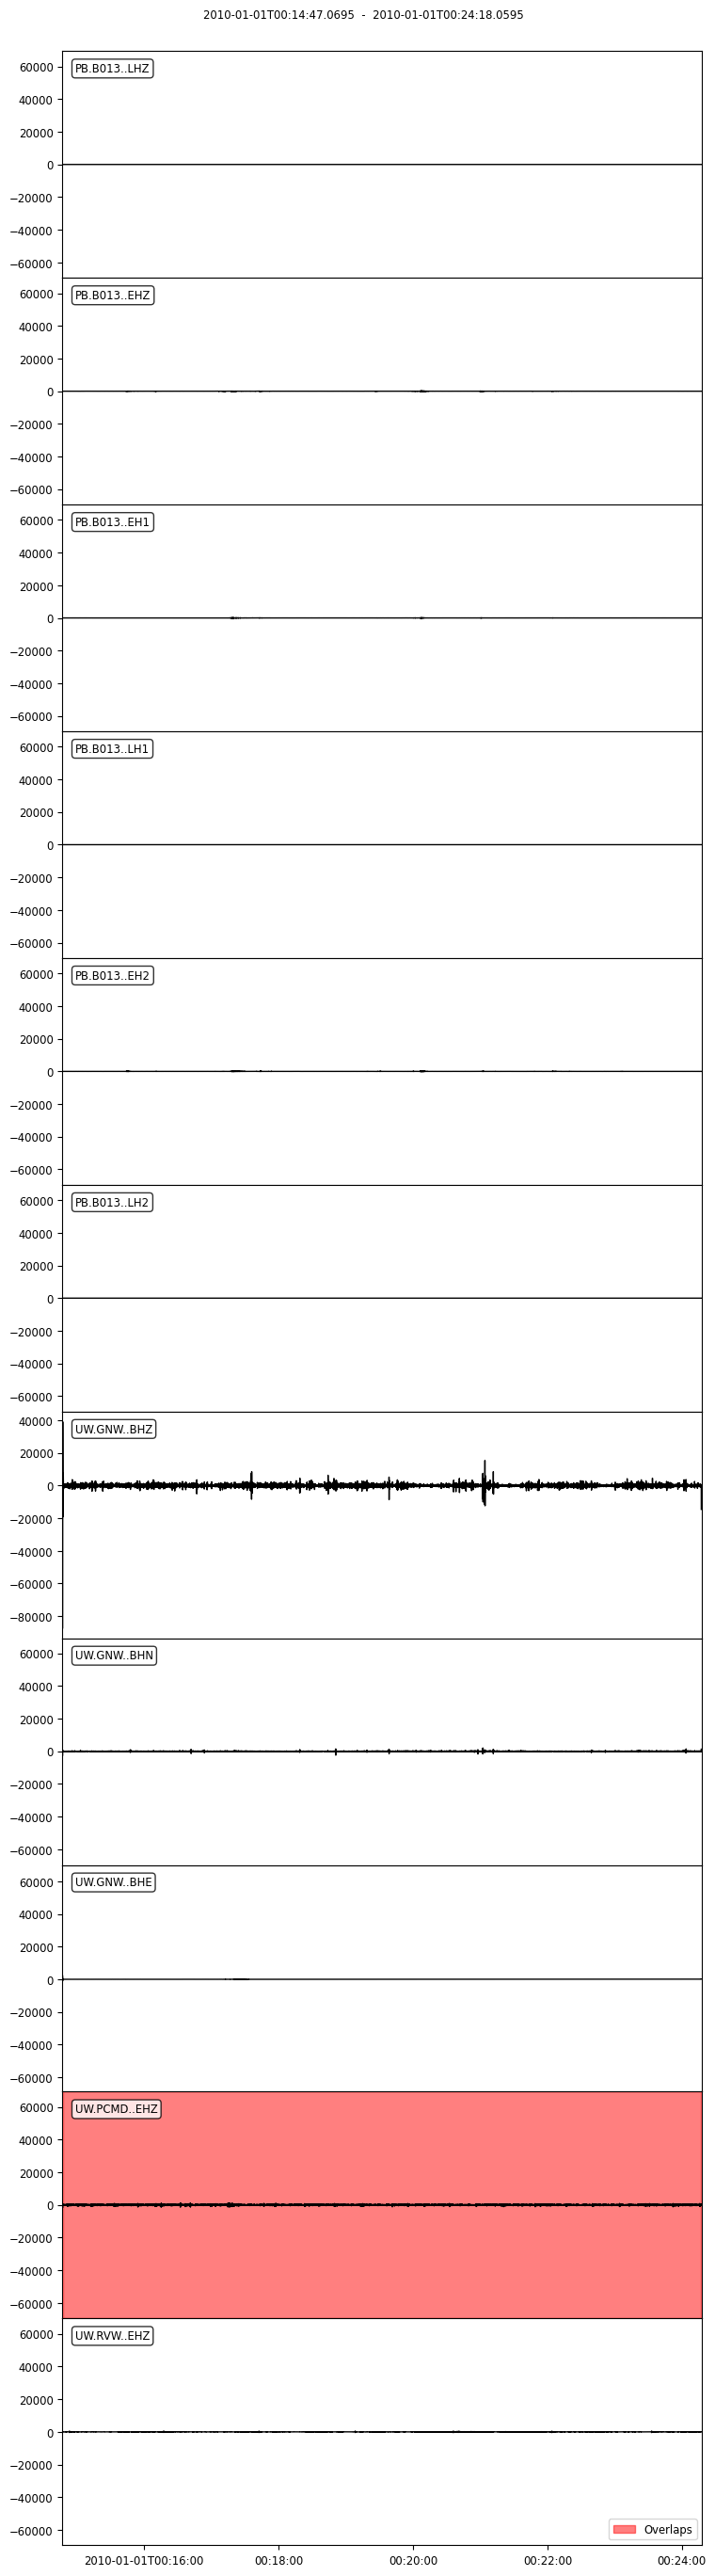

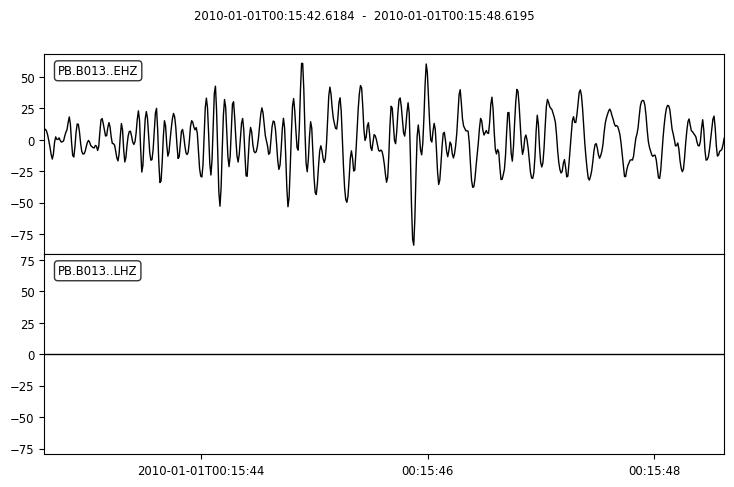

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Error processing PB.B013: Empty stream object


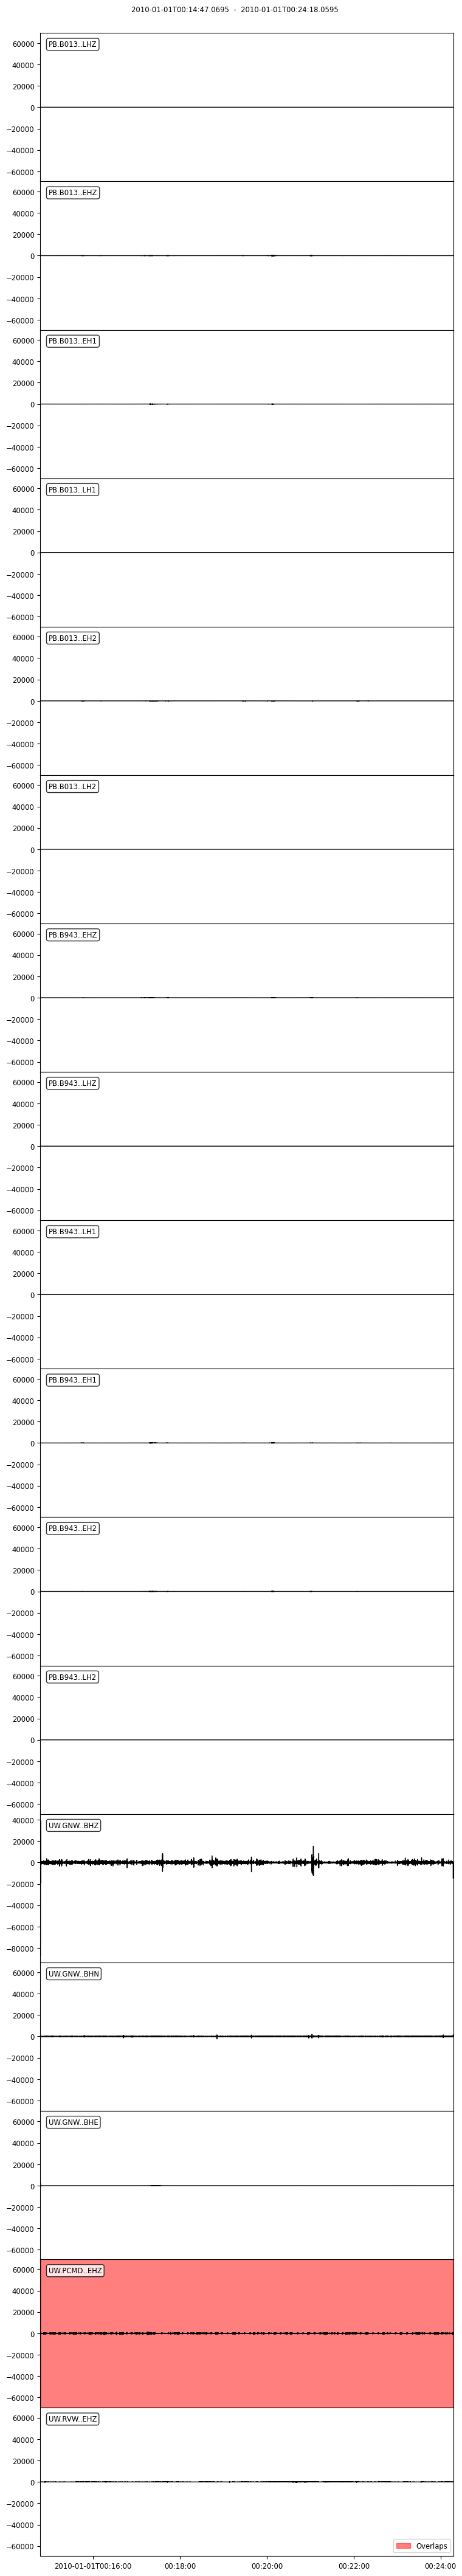

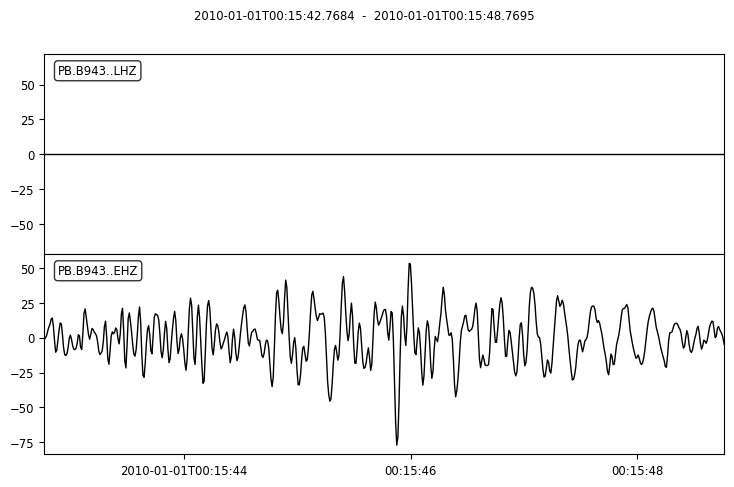

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Error processing PB.B943: Empty stream object


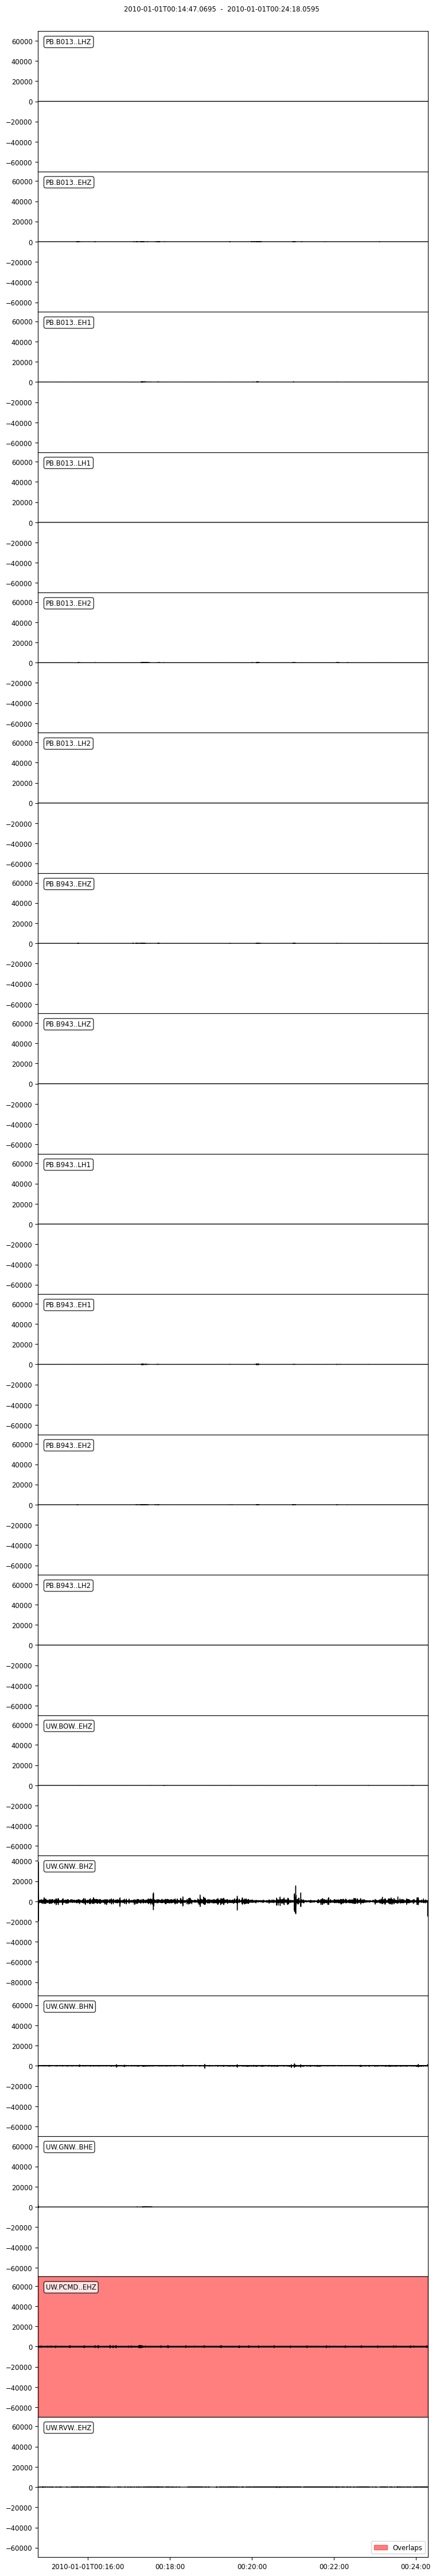

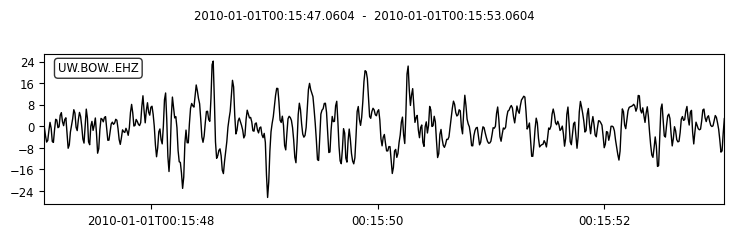

Error processing UW.BOW: Empty stream object


In [ ]:
event_id = events_df[' Event ID '].values.tolist()
st, amplitudes, origin_time = process_event(event_id[1], events_df, picks_df, source=source)


In [21]:
picks_df.keys()

Index(['Pick Time (UTC)', ' Station Name', ' Phase Type', ' Residual (s)',
       ' Event ID ', ' Pick ID '],
      dtype='str')

In [22]:
# for each event, process the waveforms and store amplitudes in a new column in picks_df
for eid in event_id:
    st, amplitudes, origin_time = process_event(eid, events_df, picks_df, source=source)
    # Store amplitudes in picks_df
    for station_key, amp in amplitudes.items():
        network, station = station_key.split('.')
        # find the row in picks_df based on any unique identifier in Station regardless of empty spaces
        station_col = picks_df[' Station Name'].str.strip()
        # find the row in picks_df based on Event ID and Station
        picks_df.loc[(picks_df[' Event ID '] == eid) & (station_col == station+"."+network), ' Amplitude '] = amp
    #print updated picks_df
    print(picks_df[picks_df[' Event ID '] == eid])

# save picks_df with amplitudes to a new csv file
picks_df.to_csv('../data/Cascadia_relocated_catalog_picks_with_amplitudes_ver_3.csv', index=False)


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


               Pick Time (UTC)  Station Name   Phase Type   Residual (s)  \
0  2010-01-01T00:15:27.180000Z       PCMD.UW            0          0.049   
1  2010-01-01T00:15:37.840400Z        RVW.UW            0          1.264   
2  2010-01-01T00:15:33.280000Z       PCMD.UW            1         -0.243   
3  2010-01-01T00:15:42.002000Z        GNW.UW            1          2.402   
4  2010-01-01T00:15:43.618400Z       B013.PB            1         -0.651   
5  2010-01-01T00:15:43.768400Z       B943.PB            1         -0.511   
6  2010-01-01T00:15:48.060400Z        BOW.UW            1         -0.263   

    Event ID    Pick ID    Amplitude   
0           0          0   431.652847  
1           0          1    29.641007  
2           0          2   431.652847  
3           0          3  1188.286410  
4           0          4     8.537054  
5           0          5     7.387344  
6           0          6    12.778104  


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at

                Pick Time (UTC)  Station Name   Phase Type   Residual (s)  \
7   2010-01-01T00:17:04.730000Z       PASS.UW            0         -0.499   
8   2010-01-01T00:17:05.008400Z       B943.PB            0         -0.252   
9   2010-01-01T00:17:05.020400Z        BLN.UW            0          0.415   
10  2010-01-01T00:17:05.150000Z        VDB.CN            0         -0.634   
11  2010-01-01T00:17:05.310400Z        MCW.UW            0         -0.116   
12  2010-01-01T00:17:07.008400Z       B001.PB            0          0.455   
13  2010-01-01T00:17:10.008400Z       B005.PB            0         -1.358   
14  2010-01-01T00:17:10.018400Z       B007.PB            0         -1.361   
15  2010-01-01T00:17:10.720000Z        HNB.CN            0         -0.653   
16  2010-01-01T00:17:11.008400Z       B011.PB            0         -0.725   
17  2010-01-01T00:17:11.528400Z       B941.PB            0         -1.718   
18  2010-01-01T00:17:14.460000Z       GOBB.CN            0          0.378   

...

                  Pick Time (UTC)  Station Name   Phase Type   Residual (s)  \
1554  2010-01-06T13:31:12.628400Z       B932.PB            0         -0.024   
1555  2010-01-06T13:31:13.098400Z       B047.PB            0         -0.020   
1556  2010-01-06T13:31:16.068400Z       B049.PB            0          0.149   
1557  2010-01-06T13:31:18.528400Z       B935.PB            0          0.582   
1558  2010-01-06T13:31:42.468400Z       B036.PB            0          0.431   
1559  2010-01-06T13:31:42.498400Z       B035.PB            0          0.501   
1560  2010-01-06T13:31:54.458400Z       B033.PB            0          0.734   
1561  2010-01-06T13:31:16.288400Z       B046.PB            1          0.392   
1562  2010-01-06T13:31:16.508400Z       B932.PB            1         -0.572   
1563  2010-01-06T13:31:17.368400Z       B047.PB            1         -0.602   
1564  2010-01-06T13:31:22.588400Z       B049.PB            1         -0.345   
1565  2010-01-06T13:31:26.838400Z       B935.PB     

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


                  Pick Time (UTC)  Station Name   Phase Type   Residual (s)  \
1569  2010-01-06T13:32:19.058400Z       B046.PB            0          0.072   
1570  2010-01-06T13:32:19.188400Z       B932.PB            0         -0.100   
1571  2010-01-06T13:32:19.718400Z       B047.PB            0          0.082   
1572  2010-01-06T13:32:22.668400Z       B049.PB            0          0.144   
1573  2010-01-06T13:32:25.078400Z       B935.PB            0         -0.091   
1574  2010-01-06T13:32:22.808400Z       B046.PB            1          0.209   
1575  2010-01-06T13:32:23.018400Z       B932.PB            1         -0.207   
1576  2010-01-06T13:32:23.778400Z       B047.PB            1         -0.114   
1577  2010-01-06T13:32:29.198400Z       B049.PB            1          0.192   
1578  2010-01-06T13:32:33.438400Z       B935.PB            1         -0.072   

       Event ID    Pick ID    Amplitude   
1569          92       1569    26.522965  
1570          92       1570    16.934606  
1

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at

KeyboardInterrupt: 